In [2]:
import pandas as pd
import numpy as np
import os, sys
from matplotlib import pyplot as plt
from scipy import stats
import pickle as pk

sys.path.append(os.path.abspath(os.path.join(os.path.dirname("../"), os.pardir)))
from customFunctions.utils import *

In [3]:
mithril_features = pd.read_csv("../checkpoints/mithril_features.csv", sep="\t", index_col="Mithril_id")
mithril_features

,PhastCons_100V,PhyloP_100V,MLC_score,closest_modification,closest_modification_2D,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,PWM_score,ddG,x_coord,y_coord,z_coord
Mithril_id,,,,,,,,,,,,,,,
MITHRIL.1941,0.016,-1.211,0.519343,428,68.0,0.063046,0.734159,0.414031,1.007675,5.0,1.554394,0.0,74.989870,3.792304,-17.815130
MITHRIL.1942,0.016,-1.211,0.519343,428,68.0,0.063046,0.027632,0.414031,1.007675,5.0,-3.177276,0.0,74.989870,3.792304,-17.815130
MITHRIL.1943,0.016,-1.211,0.519343,428,68.0,0.063046,0.175004,0.414031,1.007675,5.0,-0.514311,0.0,74.989870,3.792304,-17.815130
MITHRIL.1944,0.984,8.630,0.536906,427,67.0,0.943580,0.005642,0.431192,0.690667,5.0,-5.469367,0.0,78.754455,2.011318,-16.298545
MITHRIL.1945,0.984,8.630,0.536906,427,67.0,0.943580,0.020433,0.431192,0.690667,5.0,-3.612731,0.0,78.754455,2.011318,-16.298545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.9683,0.000,-1.952,0.681815,160,63.0,0.331219,0.227366,0.414689,1.237161,4.0,-0.136909,0.0,-39.321650,77.760650,-31.156100
MITHRIL.9684,0.000,-1.952,0.681815,160,63.0,0.331219,0.035675,0.414689,1.237161,4.0,-2.808957,-0.2,-39.321650,77.760650,-31.156100
MITHRIL.9685,0.000,-0.833,0.709337,161,64.0,0.643931,0.186358,0.284371,0.908297,3.0,-0.423848,0.0,-31.769100,74.606700,-33.021850


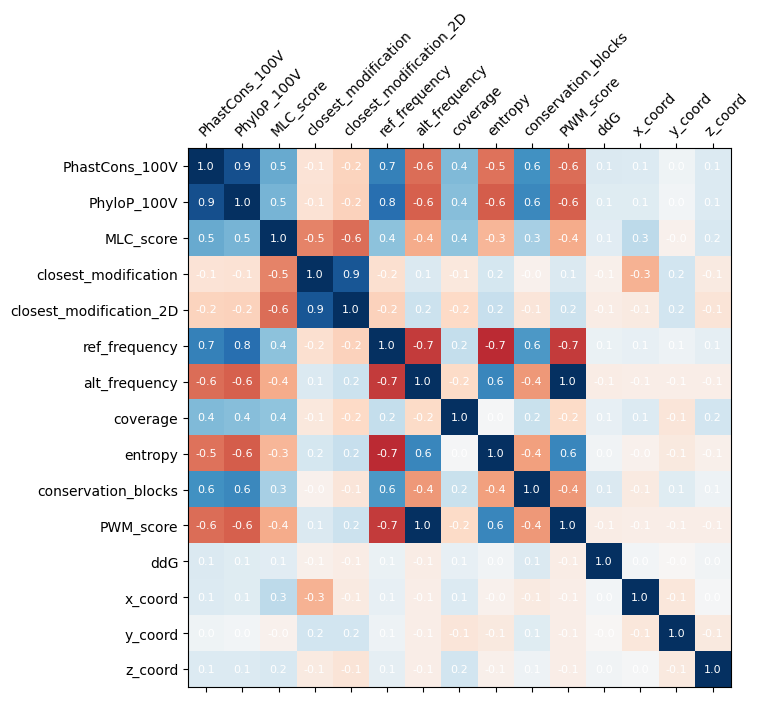

In [4]:
plt.figure(figsize=(7,7))
plt.matshow(
    mithril_features.corr(method="spearman"),
    cmap="RdBu", aspect="auto", fignum=0, vmin=-1, vmax=1
)
for i in range(mithril_features.shape[1]):
    for j in range(mithril_features.shape[1]):
        plt.text(
            i, j, f"{mithril_features.corr(method='spearman').iloc[i, j]:.1f}",
            ha="center", va="center", color="w", fontsize=8
        )
plt.xticks(range(mithril_features.shape[1]), mithril_features.columns, rotation=45, rotation_mode="anchor", ha="left")
plt.yticks(range(mithril_features.shape[1]), mithril_features.columns)
plt.show()

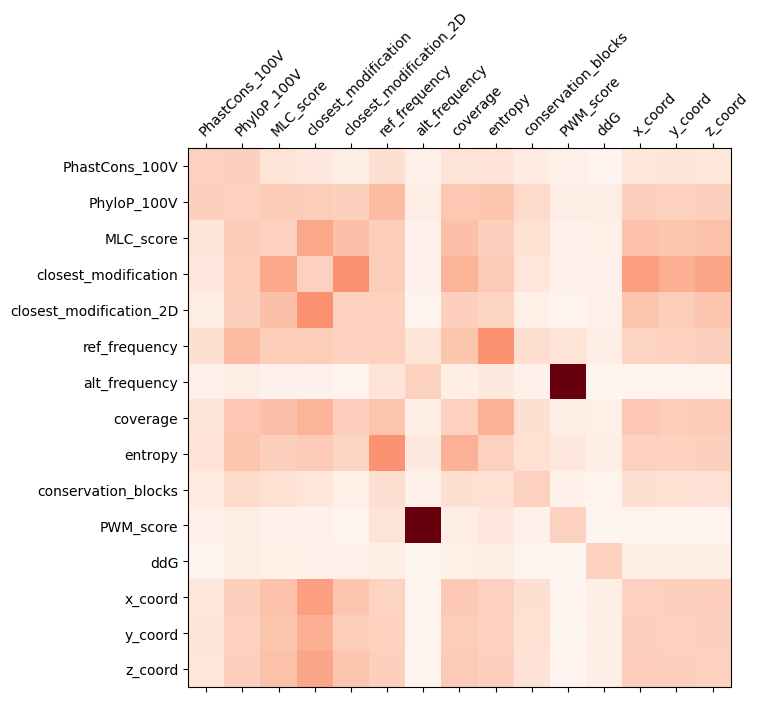

In [ ]:
from sklearn.feature_selection import mutual_info_regression
plt.figure(figsize=(7,7))
plt.matshow(
    mithril_features.corr(lambda x, y: mutual_info_regression(x[:,None], y, n_neighbors=5)),
    cmap="Reds", aspect="auto", fignum=0, vmin=0
)
plt.xticks(range(mithril_features.shape[1]), mithril_features.columns, rotation=45, rotation_mode="anchor", ha="left")
plt.yticks(range(mithril_features.shape[1]), mithril_features.columns)
plt.show()

In [2]:
model = pk.load(open("../checkpoints/candidate_models/model_rf.pk", "rb"))
model

Pipeline(steps=[('input_selection',
                 ColumnTransformerDF(transformers=[('feature_selection',
                                                    SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                       random_state=777),
                                                                      threshold=0.01),
                                                    Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'closest_modification',
       'closest_modification_2D', 'ref_frequency', 'alt_frequency', 'coverage',
       'entropy'...
                 GridSearchOOB_BinaryClassifier(estimator=BalancedRandomForestClassifier(bootstrap=True,
                                                                                         criterion='entropy',
                                                                                         max_depth=9,
                                                                                         max_features=0.1,
                                                                                         n_estimators=4096,
                                                                                         n_jobs=-1,
                                                                                         oob_score=True,
                                                                                         sampling_strategy={0: 22,
                                                                                                            1: 22}),
                                                n_jobs=16,
                                                param_grid=<sklearn.model_selection._search.ParameterGrid object at 0x7b3a10c9d010>,
                                                scoring_function=<function roc_auc_score at 0x7b3a128b5d00>,
                                                verbose=99))])

In [47]:
feature_importance = pd.DataFrame(
    [tree.feature_importances_ for tree in model[-1].estimator.estimators_],
    columns=model[-1].estimator.feature_names_in_
)
feature_importance

,PhyloP_100V,MLC_score,closest_modification,ref_frequency,coverage,entropy,ddG,x_coord,y_coord,z_coord,PC_1,PC_2,PC_3,PC_4,PC_5
0,0.000000,0.194200,0.000000,0.079807,0.000000,0.000000,0.000000,0.322166,0.042493,0.000000,0.000000,0.140373,0.110329,0.110633,0.000000
1,0.094695,0.000000,0.000000,0.074195,0.162041,0.147738,0.000000,0.409315,0.000000,0.000000,0.000000,0.000000,0.112017,0.000000,0.000000
2,0.000000,0.000000,0.255534,0.653556,0.000000,0.000000,0.000000,0.000000,0.000000,0.090911,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.126099,0.285377,0.493110,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.095414
4,0.063198,0.062611,0.045455,0.000000,0.495397,0.047724,0.000000,0.000000,0.000000,0.000000,0.000000,0.204438,0.000000,0.081177,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4091,0.000000,0.000000,0.122493,0.143340,0.000000,0.000000,0.285217,0.000000,0.132162,0.056448,0.260341,0.000000,0.000000,0.000000,0.000000
4092,0.117894,0.000000,0.328102,0.000000,0.000000,0.147568,0.000000,0.000000,0.000000,0.000000,0.406436,0.000000,0.000000,0.000000,0.000000
4093,0.028048,0.345380,0.000000,0.000000,0.000000,0.000000,0.015959,0.158120,0.149517,0.049339,0.000000,0.000000,0.148454,0.105182,0.000000
4094,0.000000,0.026185,0.000000,0.249964,0.211589,0.000000,0.000000,0.000000,0.193690,0.158540,0.000000,0.000000,0.160032,0.000000,0.000000


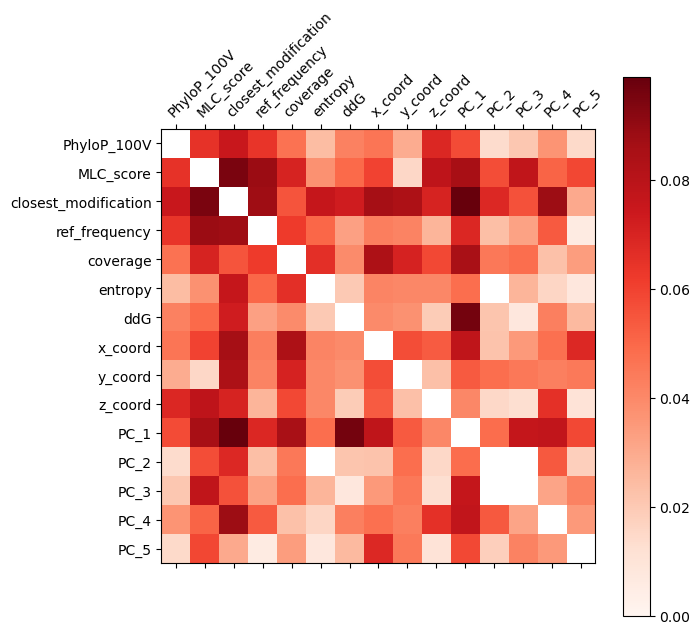

In [59]:
plt.figure(figsize=(7,7))
# we take the negative importance correlation among all trees as an indicator of collinearity:
# idea is simple: if feature `x_1` correlates with feature `x_2`, the more the tree uses `x_1`, the less that tree uses `x_2`
plt.matshow(
    -feature_importance.corr(method="spearman").mask(lambda x: x>0),
    cmap="Reds", aspect="equal", fignum=0, vmin=0
)
plt.xticks(range(feature_importance.shape[1]), feature_importance.columns, rotation=45, rotation_mode="anchor", ha="left")
plt.yticks(range(feature_importance.shape[1]), feature_importance.columns)
plt.colorbar()
plt.show()

In [80]:
feature_importance.corr(lambda x, y: stats.spearmanr(x, y)[1])

,PhyloP_100V,MLC_score,closest_modification,ref_frequency,coverage,entropy,ddG,x_coord,y_coord,z_coord,PC_1,PC_2,PC_3,PC_4,PC_5
PhyloP_100V,1.000000,3.527404e-05,1.700774e-06,4.188908e-05,2.658754e-03,0.123934,6.572954e-03,3.372628e-03,6.058685e-02,1.165258e-05,2.282393e-04,0.374337,1.877325e-01,1.915575e-02,0.355527
MLC_score,0.000035,1.000000e+00,1.109834e-09,1.501136e-08,7.165063e-06,0.017368,1.635803e-03,1.374401e-04,3.327021e-01,5.180547e-07,4.964954e-08,0.000267,6.663974e-07,1.142677e-03,0.000186
closest_modification,0.000002,1.109834e-09,1.000000e+00,1.895833e-08,4.059432e-04,0.000001,3.628869e-06,3.685311e-08,8.085067e-08,7.023814e-06,2.227823e-10,0.000013,3.530272e-04,1.719275e-08,0.054215
ref_frequency,0.000042,1.501136e-08,1.895833e-08,1.000000e+00,7.034069e-05,0.001341,3.714445e-02,5.922121e-03,7.739962e-03,8.877625e-02,1.134229e-05,0.132781,3.912600e-02,6.288308e-04,0.727687
coverage,0.002659,7.165063e-06,4.059432e-04,7.034069e-05,1.000000e+00,0.000025,1.217622e-02,8.423860e-08,6.093842e-06,1.909098e-04,5.526303e-08,0.003949,2.089860e-03,1.474144e-01,0.029894
entropy,0.123934,1.736832e-02,1.087115e-06,1.340780e-03,2.465329e-05,1.000000,2.034801e-01,8.742965e-03,9.644658e-03,9.939135e-03,2.102282e-03,0.914942,9.104947e-02,3.140500e-01,0.616562
ddG,0.006573,1.635803e-03,3.628869e-06,3.714445e-02,1.217622e-02,0.203480,1.000000e+00,1.095317e-02,1.709933e-02,2.193555e-01,7.223648e-10,0.170854,6.148485e-01,6.469969e-03,0.109727
x_coord,0.003373,1.374401e-04,3.685311e-08,5.922121e-03,8.423860e-08,0.008743,1.095317e-02,1.000000e+00,2.635654e-04,6.445155e-04,5.838648e-07,0.159524,2.548149e-02,2.506395e-03,0.000013
y_coord,0.060587,3.327021e-01,8.085067e-08,7.739962e-03,6.093842e-06,0.009645,1.709933e-02,2.635654e-04,1.000000e+00,1.381316e-01,5.866231e-04,0.002088,3.820184e-03,6.361493e-03,0.004238
z_coord,0.000012,5.180547e-07,7.023814e-06,8.877625e-02,1.909098e-04,0.009939,2.193555e-01,6.445155e-04,1.381316e-01,1.000000e+00,9.476062e-03,0.340969,4.232253e-01,2.681923e-05,0.506976


In [64]:
common_features = feature_importance.columns.intersection(mithril_features.columns)
common_features

Index(['PhyloP_100V', 'MLC_score', 'closest_modification', 'ref_frequency',
       'coverage', 'entropy', 'ddG', 'x_coord', 'y_coord', 'z_coord'],
      dtype='object')

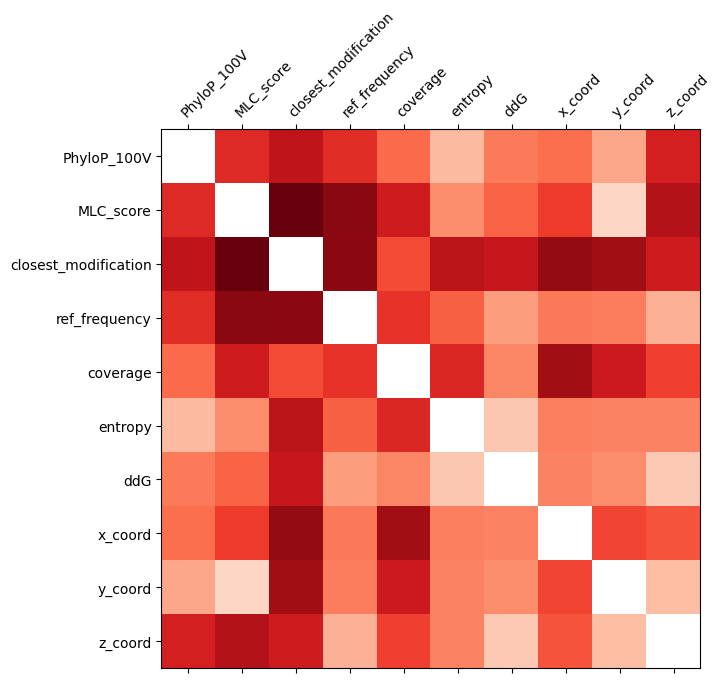

In [68]:
plt.figure(figsize=(7,7))
plt.matshow(
    -feature_importance[common_features].corr(method="spearman").mask(lambda x: x>0),
    cmap="Reds", aspect="equal", fignum=0, vmin=0
)
plt.xticks(range(len(common_features)), common_features, rotation=45, rotation_mode="anchor", ha="left")
plt.yticks(range(len(common_features)), common_features)
plt.show()

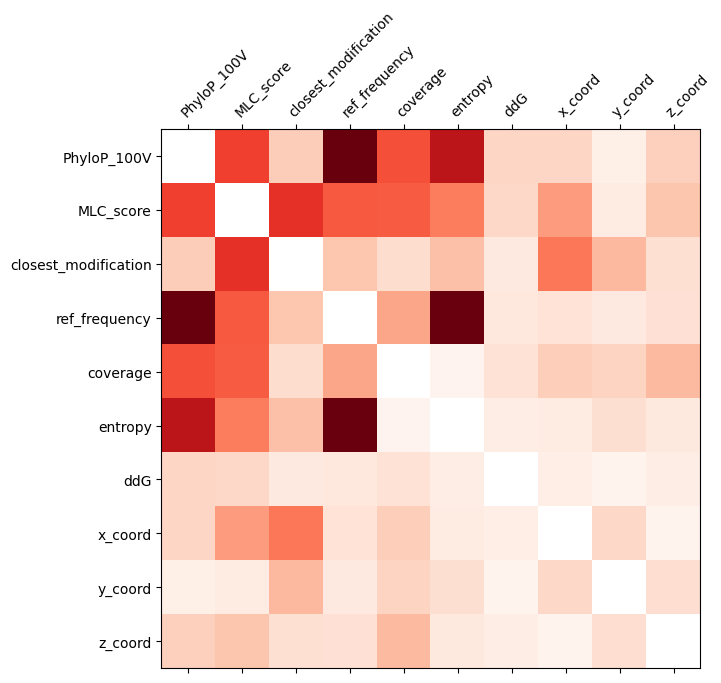

In [77]:
plt.figure(figsize=(7,7))
plt.matshow(
    mithril_features[common_features].corr(method="spearman").abs().mask(lambda x: x==1),
    cmap="Reds", aspect="equal", fignum=0, vmin=0
)
plt.xticks(range(len(common_features)), common_features, rotation=45, rotation_mode="anchor", ha="left")
plt.yticks(range(len(common_features)), common_features)
plt.show()

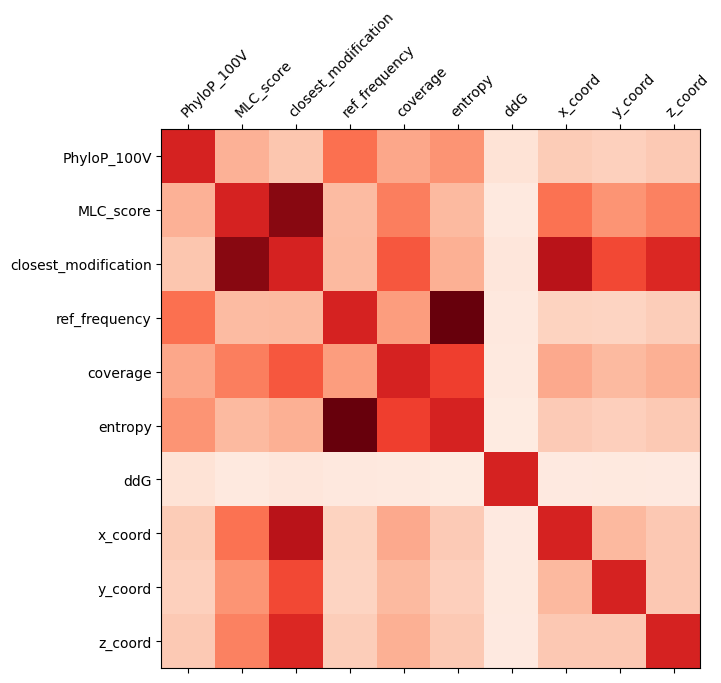

In [94]:
plt.figure(figsize=(7,7))
plt.matshow(
    mithril_features[common_features].corr(lambda x, y: mutual_info_regression(x[:,None], y, n_neighbors=10)),
    cmap="Reds", aspect="equal", fignum=0, vmin=0
)
plt.xticks(range(len(common_features)), common_features, rotation=45, rotation_mode="anchor", ha="left")
plt.yticks(range(len(common_features)), common_features)
plt.show()

In [99]:
model["input_selection"]["feature_selection"].estimator_.

DecisionTreeClassifier(class_weight='balanced', random_state=777)